# Модель для прогнозирования оттока клиентов для сервиса доставки кофе <a id='start'></a>
- Автор: Якунина Анна
- Дата: 28.05.2026  

## Цели и задачи проекта
### Цель проекта - разработать модель бинарной классификации, которая спрогнозирует вероятность оттока каждого клиента в следующем месяце.
 ### Задачи проекта
1. Сформулировать задачу машинного обучения.
2. Провести исследовательский анализ данных.
3. Обучить модель с использованием кросс-валидации.
4. Создать новые признаки.
5. Провести эксперименты с гиперпараметрами модели и выбрать лучшую.
6. Подготовить финальную модель.
7. Сформулировать итоговый вывод и рекомендации для заказчика.
8. Сохранить артефакты для продакшена.

## Описание данных
Данные датасета `coffee_churn_dataset.csv` содержат следующие поля:
- `user_id` — идентификатор пользователя;
- `days_since_last_order` — количество дней, прошедших с последнего заказа;
- `order_frequency_month` — среднее число заказов в месяц;
- `order_frequency_week` — среднее число заказов в неделю;
- `avg_order_value` — средний чек, в рублях;
- `median_order_value` — медианный чек, в рублях;
- `total_spent_last_month` — сумма заказов за последний месяц;
- `total_spent_last_week` — сумма заказов за последнюю неделю;
- `discount_usage_rate` — доля заказов со скидкой за последний месяц;
- `last_coffee_type` — сорт кофе, купленный пользователем в последний раз на момент сбора данных;
- `preferred_roast` — предпочитаемый тип обжарки;
- `milk_preference` — предпочитаемый тип молока;
- `seasonal_menu_tried` — отметка о том, пробовал ли пользователь новейшее сезонное меню;
- `coffee_bean_origin` — страна происхождения зерна;
- `last_drink_size` — размер последнего заказа, совершённого на момент сбора данных;
- `subscription_status` — тип подписки пользователя;
- `app_opens_per_week` — сколько раз за неделю пользователь в среднем открывал приложение доставки кофе;
- `notifications_enabled` — включены ли у пользователя уведомления;
- `review_rating_last_10` — средняя оценка последних на момент сбора данных десяти заказов клиента;
- `review_rating_last_1` — оценка последнего на момент сбора данных заказа клиента;
- `app_crashes_last_month` — сколько раз приложение зависало за последний месяц;
- `seasons` — текущее время года;
- `days_since_last_promo` — сколько дней прошло с последнего использования акции или промокода;
- `phone_type` — тип устройства, с которого пользователь чаще всего совершал покупки;
- `coffee_preference_change` — менялись ли вкусовые предпочтения пользователя;
- `geo_id` — идентификатор региона пользователя;
- `churn` — перестал ли пользователь пользоваться сервисом.

## Содержимое проекта
1. [Постановка задачи машинного обучения](#task)
2. [Подключение и настройка библиотек](#libs)
3. [Константы/Config](#config)
4. [Загрузка датасета](#upload)
5. [Исследовательский анадиз данных](#research)
6. [Предобработка данных](#preprocess)
7. [Обучение модели](#train)
8. [Создание новых признаков](#new_features)
9. [Эксперименты с гиперпараметрами](#experiments)
10. [Подготовка финальной модели](#final)
11. [Отчёт о проделанной работе](#resume)
12. [Сохранение модели для продакшена](#save)

---
## 1. Постановка задачи машинного обучения <a id = 'task'></a>
- **Тип задачи** - задача бинарной классификации:
    - необходимо построить модель бинарной классификации, которая спрогнозирует вероятность оттока каждого клиента в следующем месяце.
- **Целевая переменная** - поле `churn` (перестал ли пользователь пользоваться сервисом):
    - **сhurn = 1** (положительный класс): клиент с высокой вероятностью откажется от услуг компании в следующем месяце;
    - **churn = 0** (отрицательный класс): клиент продолжит пользоваться сервисом.
- **Метрики качества модели**
    - **Precision-Recall AUC (PR AUC)** - основная метрика;
    - **Precision**;
    - **Recall**.
- **Технические требования к реализации**
    - Базовая модель: **LogisticRegression**.
    - Воспроизводимость:
        - все эксперименты должны быть воспроизводимы.
    - Валидация:
        - использование **кросс-валидации** для оценки модели.
    - Подготовка к внедрению:
        - сохранение итоговой модели и пайплайна предобработки для дальнейшего использования в промышленной эксплуатации.

---
## 2. Подключение и настройка библиотек <a id = 'libs'></a>

- Загружаем необходимые библиотеки Python

In [1]:
!pip install phik -U -q

In [2]:
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from phik import phik_matrix

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from category_encoders import TargetEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, FunctionTransformer, OrdinalEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, average_precision_score, precision_score, recall_score

In [3]:
%pip freeze > requirments.txt

Note: you may need to restart the kernel to use updated packages.


---
## 3. Константы/Config <a id='config'></a>

In [4]:
RANDOM_STATE = 42
N_FOLDS = 5

pd.set_option('display.max_columns', None)

## 4. Загрузка датасета <a id = 'upload'></a>
### 4.1. Загрузка данных и общие сведения

- Загружаем данные из файла  `datasets/coffee_churn_dataset.csv`

In [5]:
df = pd.read_csv('datasets/coffee_churn_dataset.csv', sep=',', decimal='.')

- Знакомимся с данными датасета `coffee_churn_dataset.csv`

In [6]:
df.head(5)

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,light,almond,NaN,vietnam,large,pro,30.468321,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,light,whole,1.0,guatemala,medium,none,NaN,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,medium,oat,1.0,guatemala,small,premium,17.895637,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,medium,skim,0.0,brazil,medium,none,11.405533,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,dark,almond,1.0,colombia,medium,none,15.948239,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   str    
 14  last_drink_size  

- Создаём списки категориальных и целочисленных признаков:

In [8]:
cat_features = ['last_coffee_type', 'preferred_roast', 'milk_preference', 'coffee_bean_origin', 'last_drink_size', 'subscription_status', 'seasons', 'phone_type', 'geo_location']

In [9]:
int_features = ['days_since_last_order', 'seasonal_menu_tried', 'notifications_enabled', 'app_crashes_last_month', 'days_since_last_promo', 'coffee_preference_change', 'churn']

#### Вывод
Датасет `coffee_churn_dataset.csv` содержит **10450 строк и 27 столбцов**:
- Столбцы с категориальными признаками `last_coffee_type`, `preferred_roast`, `milk_preference`, `coffee_bean_origin`, `last_drink_size`, `subscription_status`, `seasons`, `phone_type`, `geo_location` и `user_id` содержат строковые данные, представлены типом `str`. Следует привести к типу `object`.
- Столбцы: `days_since_last_order`, `seasonal_menu_tried`, `notifications_enabled`, `app_crashes_last_month`, `days_since_last_promo`, `coffee_preference_change`, `churn` содержат целочисленные числовые данные. Их следует привести к типу `integer` и оптимизировать размерность.
- Пропуски содержатся во всех столбцах, кроме `user_id` и `churn`.
- Значения в столбцах соответствуют описанию.

---
### 4.2. Предобработка данных
- Преобразуем типы данных датафрейма `df`

In [10]:
for col in cat_features + ['user_id']:
    df[col] = df[col].astype('object')

for col in int_features:
    df[col] = df[col].astype('Int16')
    df[col] = pd.to_numeric(df[col], errors='coerce', downcast='integer')       

In [11]:
df.dtypes

user_id                      object
days_since_last_order          Int8
order_frequency_month       float64
order_frequency_week        float64
avg_order_value             float64
median_order_value          float64
total_spent_last_month      float64
total_spent_last_week       float64
discount_usage_rate         float64
last_coffee_type             object
preferred_roast              object
milk_preference              object
seasonal_menu_tried            Int8
coffee_bean_origin           object
last_drink_size              object
subscription_status          object
app_opens_per_week          float64
notifications_enabled          Int8
review_rating_last_10       float64
review_rating_last_1        float64
app_crashes_last_month         Int8
seasons                      object
days_since_last_promo         Int16
phone_type                   object
coffee_preference_change       Int8
geo_location                 object
churn                          Int8
dtype: object

#### Выводы
- Столбцы с категориальными признаками `last_coffee_type`, `preferred_roast`, `milk_preference`, `coffee_bean_origin`, `last_drink_size`, `subscription_status`, `seasons`, `phone_type`, `geo_location` и `user_id` привели к типу `object`.
- Столбцы: `days_since_last_order`, `seasonal_menu_tried`, `notifications_enabled`, `app_crashes_last_month`, `days_since_last_promo`, `coffee_preference_change`, `churn` привели к типу `integer` и оптимизировали размерность.

---
## 5. Исследовательский анализ данных <a id = 'research'></a>

### 5.1. Целевая переменная

- Изучим распределение значений по столбцу `churn`	

In [12]:
def analize_feature(df, col, rot=45, figsize=(7, 3)):
    df[col].value_counts(dropna=False, normalize=True).plot(
        kind='bar',
        figsize=figsize,
        grid=True,
        rot=rot
    )

    plt.title(f'Распределение по категориям - {col}')
    plt.xlabel('Категория')
    plt.ylabel('Количество')

    plt.show()
    
    cat = df[[col]].value_counts(dropna=False).reset_index()
    cat.index += 1
    cat.columns = [col, 'Кол-во']
    cat['Доля'] = cat['Кол-во'] / len(df)
    cat['Доля'] = cat['Доля'].round(2)

    return cat

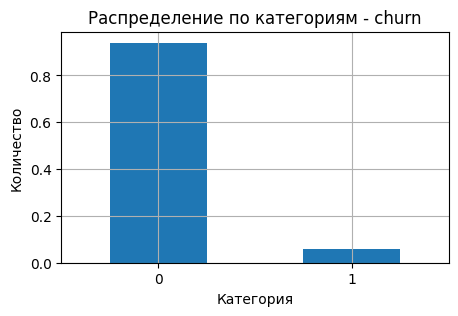

,churn,Кол-во,Доля
1,0,9821,0.94
2,1,629,0.06


In [13]:
analize_feature(df, 'churn', rot=0, figsize=(5, 3))

#### Выводы
Анализ распределения показывает наличие **сильного дисбаланса** классов:
- **0** - доминирующий класс: **94%**. Клиенты, которые остались с сервисом.
- **1** - редкий класс: **6%**. Клиенты, которые перестали пользоваться сервисом.

---
### 5.2. Описание признаков

- **Технические данные**:
    - `user_id` - уникальный идентификатор пользователя. Используется только для идентификации строк.
    - `geo_location` - идентификатор региона. Может быть полезен для анализа географических различий в поведении.
    - `phone_type` - тип устройства. Может косвенно указывать на привычки пользователя или технические проблемы с приложением.
- **Поведенческие метрики**:
    - `days_since_last_order` - чем больше дней прошло с последнего заказа, тем выше вероятность оттока;
    - `order_frequency_month`, `order_frequency_week`- частота заказов. Снижение частоты — явный признак потери интереса;
    - `avg_order_value`, `median_order_value` - cредний и медианный чек. Помогают сегментировать клиентов по их ценности для бизнеса;
    - `total_spent_last_month`, `total_spent_last_week`- динамика трат. Резкое падение может сигнализировать об оттоке;
    - `days_since_last_promo`- количестыо дней с последнего использования акции или промокода. Может указывать на то, что пользователь был активен только благодаря скидкам;
    - `app_opens_per_week` - частота взаимодействия с приложением. Низкая активность — фактор риска;
    - `app_crashes_last_month` - количество сбоев приложения. Технический фактор, который может напрямую вызывать отток из-за негативного пользовательского опыта.
- **Предпочтения пользователей**:
    - `last_coffee_type`, `preferred_roast`, `milk_preference`, `coffee_bean_origin`, `last_drink_size` - детализированные предпочтения. Позволяют понять, что именно покупал пользователь.
    - `coffee_preference_change` - флаг изменения предпочтений. Может быть как положительным (пользователь ищет новое), так и отрицательным (не нашел нужного) сигналом.
    - `seasonal_menu_tried` - пробовал ли пользователь сезонное меню. Показатель вовлеченности и интереса к новинкам.
- **Взаимодействие с сервисом и обратная связь**:
    - `subscription_status` - тип подписки. Пользователи с подпиской менее склонны к оттоку, чем "разовые" покупатели. Очень важный признак.
    - `notifications_enabled` - включены ли уведомления. Если отключены, канал коммуникации с пользователем закрыт.
    - `review_rating_last_10`, `review_rating_last_1` - оценки заказов. Низкие оценки — прямой индикатор недовольства сервисом или продуктом.
- **Контекстуальные**:
    - `seasons` - текущее время года. Может влиять на спрос (например, рост потребления горячих напитков зимой).

- **Важные признаки**:
    - поведенческие метрики;
    - взаимодействие с сервисом и обратная связь;
    - `phone_type`.
- **Малоинформативные или избыточные**:
    - идентификаторы: `user_id`, `geo_location`;
    - предпочтения пользователей;
    - `seasons`.

- Для построения базовой модели оттока **следует удалить следующие признаки**:
    - `user_id` - технический идентификатор, а не характеристика пользователя. Он не несет никакой информации о поведении или склонности к оттоку.
    - `last_coffee_type`, `preferred_roast`, `milk_preference`, `coffee_bean_origin`, `last_drink_size` - вкусовые предпочтения. Эти данные могут быть полезны для маркетинговой сегментации, но не для прогнозирования churn. Они усложняют модель и могут привести к переобучению.
    - `geo_location` - технический идентификатор. Сам по себе он не информативен.
    - `coffee_preference_change` - признак является производным от других данных о предпочтениях. Cмена предпочтений может означать как поиск нового вкуса (вовлеченность), так и разочарование в старом (риск оттока). Вносит шум в модель.
    - `seasons`- признак не информативен, поcкольку данные агрегированы за последние 4 недели.

- Сохраняем количество строк и столбцов в датафрейме:

In [14]:
len_src_df = len_df = len(df)
cols_src_df = cols_df = df.shape[1]
print(f'Всего строк: {len_src_df}')
print(f'Всего столбцов: {cols_src_df}')

Всего строк: 10450
Всего столбцов: 27


- Удаляем неинформативные признаки:

In [15]:
columns_to_drop = [ 'user_id', 'last_coffee_type', 'preferred_roast', 'milk_preference', 'coffee_bean_origin', 'last_drink_size', 'geo_location', 'coffee_preference_change', 'seasons']

In [16]:
df = df.drop(columns=columns_to_drop)

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   days_since_last_order   9505 non-null   Int8   
 1   order_frequency_month   9850 non-null   float64
 2   order_frequency_week    10062 non-null  float64
 3   avg_order_value         9867 non-null   float64
 4   median_order_value      9619 non-null   float64
 5   total_spent_last_month  10156 non-null  float64
 6   total_spent_last_week   9506 non-null   float64
 7   discount_usage_rate     10053 non-null  float64
 8   seasonal_menu_tried     9461 non-null   Int8   
 9   subscription_status     9512 non-null   object 
 10  app_opens_per_week      9554 non-null   float64
 11  notifications_enabled   9913 non-null   Int8   
 12  review_rating_last_10   9757 non-null   float64
 13  review_rating_last_1    9593 non-null   float64
 14  app_crashes_last_month  9729 non-null   Int8   
 

In [18]:
del_cols = cols_df - df.shape[1]
print(f'Количество удаленных столбцов: {del_cols}')
cols_df = df.shape[1]

Количество удаленных столбцов: 9


#### Выводы
- Удалили **9 столбцов**.
- Датасет `df` содержит **10450 строк и 18 столбцов**.

---
### 5.3. Обработка пропусков

- Считаем количество пропусков в столбцах датафрейма `df` в абсолютных и относительных значениях

In [19]:
df.isna().sum() \
    .to_frame(name='Кол-во') \
    .sort_values(by='Кол-во', ascending=False) \
    .assign(Процент=lambda x: x['Кол-во'] / len(df) * 100) \
    .style.format({'Процент': '{:.2f}%'})

,Кол-во,Процент
seasonal_menu_tried,989,9.46%
days_since_last_order,945,9.04%
total_spent_last_week,944,9.03%
subscription_status,938,8.98%
app_opens_per_week,896,8.57%
review_rating_last_1,857,8.20%
median_order_value,831,7.95%
days_since_last_promo,731,7.00%
app_crashes_last_month,721,6.90%
review_rating_last_10,693,6.63%


- В датасете отсутствует от **2.8% до 9.5%** значений по различным признакам:
    - некорректное заполнение может привести к искажению результатов и снижению качества модели.
- **Влияние** пропущенных значений на данные:
    - **снижение объема обучающей выборки**. Большинство алгоритмов машинного обучения не могут работать с NaN значениями "из коробки". Удаление строк с пропусками (в некоторых случаях — почти 10%) приведет к уменьшению объема информации для обучения и, как следствие, к менее точной и надежной модели.
    - **искажение статистических показателей**. Игнорирование пропусков при расчете средних, медиан и других метрик даст смещенную картину данных.
    - **систематическая ошибка (Bias)**. Пропуски редко возникают случайно. Например, пользователи, которые давно не заказывали кофе, могли уже уйти из сервиса. У них, скорее всего, нет данных о последнем заказе. Если просто удалить этих пользователей, модель не увидит эту важную закономерность и будет плохо предсказывать отток именно для неактивных клиентов.

- Создадим списки категориальных, числовых и бинарных признаков:

In [20]:
cat_features = ['subscription_status', 'phone_type']
num_features = ['days_since_last_order', 'order_frequency_month', 'order_frequency_week', 'avg_order_value', 'median_order_value',	
                'total_spent_last_month', 'total_spent_last_week','discount_usage_rate', 'app_opens_per_week', 'review_rating_last_10',
                'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo']
binary_features = ['seasonal_menu_tried', 'notifications_enabled']

**Стратегия заполнения пропусков**
- **Категориальные признаки**:
    - заполнить пропуски категорией **'none'**.
- **Числовые признаки**:
    - заполнить пропуски **средним значением** соответствующего признака.
- **Бинарные признаки**:
    - заполнение исходного пропуска значением наиболее логичным с точки зрения бизнеса - **mode или 0**;
    - cоздание **нового признака-индикатора**, который отмечает сам факт наличия пропуска.

---
### 5.4. Анализ категориальных признаков

- Проанализируем значения в категориальных столбцах

In [21]:
cat_features

['subscription_status', 'phone_type']

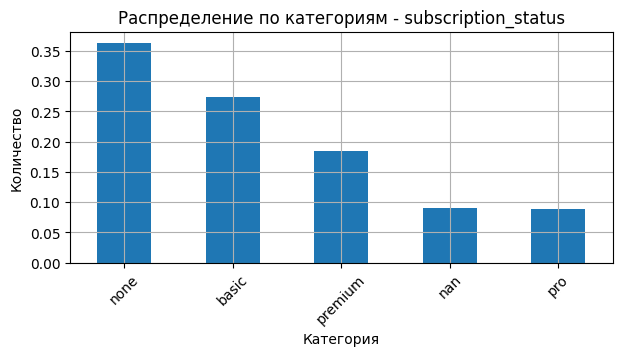

,subscription_status,Кол-во,Доля
1,none,3803,0.36
2,basic,2862,0.27
3,premium,1923,0.18
4,NaN,938,0.09
5,pro,924,0.09


In [22]:
analize_feature(df, 'subscription_status')

- Признак `subscription_status`
    - Категории распределены **неравномерно**.
    - Большинство пользователей не имеют подписки - **36%**.
    - Категория **pro** является наименее представленной - **9%**.
    - Присутствует значительное количество пропусков - **9%**.
- Метод кодирования: **Target Encoding**
    - C точки зрения бизнеса статус подписки имеет иерархический порядок.
    - Заменим категорию на число, которое отражает её связь с целевой переменной.
- Генерация **новых признаков**
    - Cоздать дополнительный числовой столбец `subscription_level`, отражающий иерархию подписок.

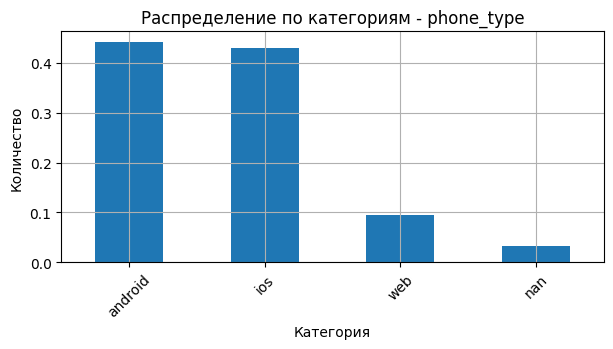

,phone_type,Кол-во,Доля
1,android,4611,0.44
2,ios,4502,0.43
3,web,1001,0.10
4,NaN,336,0.03


In [23]:
analize_feature(df, 'phone_type')

- Признак `phone_type`
     - Категории распределены **неравномерно**.
     - Категории **android и ios** доминируют и распределены почти поровну: **44% и 43%** соответственно.
     - Пропусков немного - **3%**.
- Признак может указывать на технические особенности.
- Если приложение на одной из платформ работает нестабильно, это может быть косвенным признаком для оттока пользователей.

- Проверим наличие связи между типом платформы `phone_type` и количеством зависаний приложения за последний месяц `app_crashes_last_month`

In [24]:
df.groupby('phone_type')['app_crashes_last_month'].sum() \
    .to_frame(name='Кол-во') \
    .sort_values(by='Кол-во', ascending=False) \
    .assign(Процент=lambda x: x['Кол-во'] / df.groupby('phone_type')['phone_type'].count() * 100) \
    .style.format({'Процент': '{:.2f}%'})

,Кол-во,Процент
phone_type,,
android,4320,93.69%
ios,4297,95.45%
web,962,96.10%


- Доли распределены равномерно.
- Данный признак **не информативен**. Его следует **удалить**.

In [25]:
df = df.drop(columns='phone_type')

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   days_since_last_order   9505 non-null   Int8   
 1   order_frequency_month   9850 non-null   float64
 2   order_frequency_week    10062 non-null  float64
 3   avg_order_value         9867 non-null   float64
 4   median_order_value      9619 non-null   float64
 5   total_spent_last_month  10156 non-null  float64
 6   total_spent_last_week   9506 non-null   float64
 7   discount_usage_rate     10053 non-null  float64
 8   seasonal_menu_tried     9461 non-null   Int8   
 9   subscription_status     9512 non-null   object 
 10  app_opens_per_week      9554 non-null   float64
 11  notifications_enabled   9913 non-null   Int8   
 12  review_rating_last_10   9757 non-null   float64
 13  review_rating_last_1    9593 non-null   float64
 14  app_crashes_last_month  9729 non-null   Int8   
 

In [27]:
cat_features = ['subscription_status']

- Проанализируем распределение данных по бинарным признакам `seasonal_menu_tried`, `notifications_enabled`

In [28]:
binary_features

['seasonal_menu_tried', 'notifications_enabled']

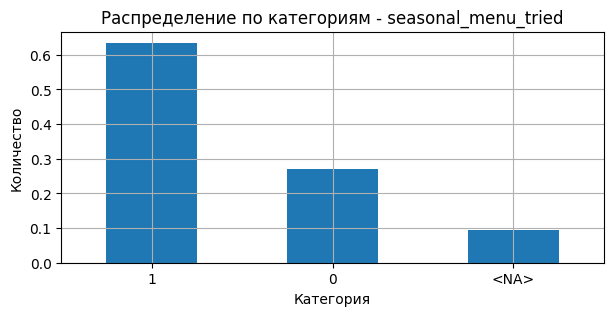

,seasonal_menu_tried,Кол-во,Доля
1,1,6634,0.63
2,0,2827,0.27
3,<NA>,989,0.09


In [29]:
analize_feature(df, 'seasonal_menu_tried', rot=0)

- Признак `seasonal_menu_tried`:
    - данные распределены неравномерно;
    - большинство пользователей пробовали ли новейшее сезонное меню (**1**) - **63%**.
    - не пробовали (**0**) - **27%**.
    - Присутствует значительное количество пропусков - **9%**.

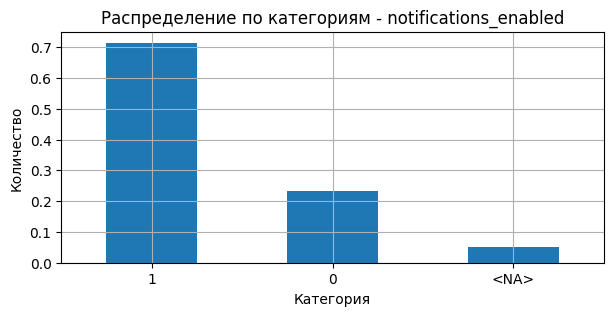

,notifications_enabled,Кол-во,Доля
1,1,7465,0.71
2,0,2448,0.23
3,<NA>,537,0.05


In [30]:
analize_feature(df, 'notifications_enabled', rot=0)

- Признак `notifications_enabled`:
    - данные распределены неравномерно;
    - большинство пользователей пробовали ли новейшее сезонное меню (**1**) - **72%**.
    - не пробовали (**0**) - **23%**.
    - Присутствует пропуски - **5%**.

In [31]:
del_cols = cols_df - df.shape[1]
print(f'Количество удаленных столбцов: {del_cols}')
cols_df = df.shape[1]

Количество удаленных столбцов: 1


#### Выводы
- Удалили **1 столбец**.
- Датасет `df` содержит **10450 строк и 17 столбцов**.

---
### 5.5. Явные и неявные дубликаты в данных

- Проверим полные дубликаты в датафрейме `df`

In [32]:
df.duplicated().sum()

np.int64(414)

- Удаляем дубликаты

In [33]:
df = df.sort_values(by=df.columns.tolist())
df = df.drop_duplicates(ignore_index=True)

- Считаем количество удаленных строк в абсолютном и относительном выражении

In [34]:
del_rows = len_df - len(df)
print(f'Количество удаленных строк: {del_rows} - {round(del_rows/ len_df * 100, 2)}%')

Количество удаленных строк: 414 - 3.96%


In [35]:
len_df = len(df)
len_df

10036

#### Выводы
- Найдено **414** явных дубликатов - **3.96%** данных.
- **Все дубликаты удалены**.
- Датафрейм `df` содержит **10036 строк и 17 столбцов**.

---
### 5.6. Распределение признаков

- Изучим статистические показатели распределения числовых признаков 

In [36]:
num_features = ['days_since_last_order', 'order_frequency_month', 'order_frequency_week', 'avg_order_value', 'median_order_value',	'total_spent_last_month', 
                'total_spent_last_week', 'discount_usage_rate', 'app_opens_per_week', 'review_rating_last_10', 'review_rating_last_1', 
                'app_crashes_last_month', 'days_since_last_promo']

In [37]:
df[num_features].describe()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,app_opens_per_week,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo
count,9134.0,9454.000000,9659.000000,9476.000000,9232.000000,9748.000000,9120.000000,9653.000000,9179.000000,9362.000000,9214.000000,9342.0,9338.0
mean,4.391285,4.025081,0.929998,1063.254822,452.643042,1945.439275,412.764040,0.283965,11.327660,4.207272,4.022551,1.015521,14.562969
std,4.853955,2.830559,0.657909,707.615045,258.899193,2375.596627,446.166446,0.158722,14.512342,0.782584,1.205782,1.010847,15.308919
min,0.0,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,0.000000,1.415526,-0.897000,0.0,0.0
25%,1.0,1.931762,0.445322,552.806327,263.584473,628.239460,136.251186,0.159470,6.335269,3.675187,3.217563,0.0,4.0
50%,3.0,3.378246,0.783019,898.368853,405.841711,1294.345827,287.099474,0.263945,9.214974,4.205958,3.989637,1.0,10.0
75%,6.0,5.434299,1.258550,1405.845229,591.515371,2475.248185,549.310546,0.386869,12.715057,4.718466,4.844709,2.0,20.0
max,40.0,27.389318,6.302624,5901.965278,2189.101644,79298.849570,8615.988952,0.887301,224.587876,7.384425,8.558443,7.0,140.0


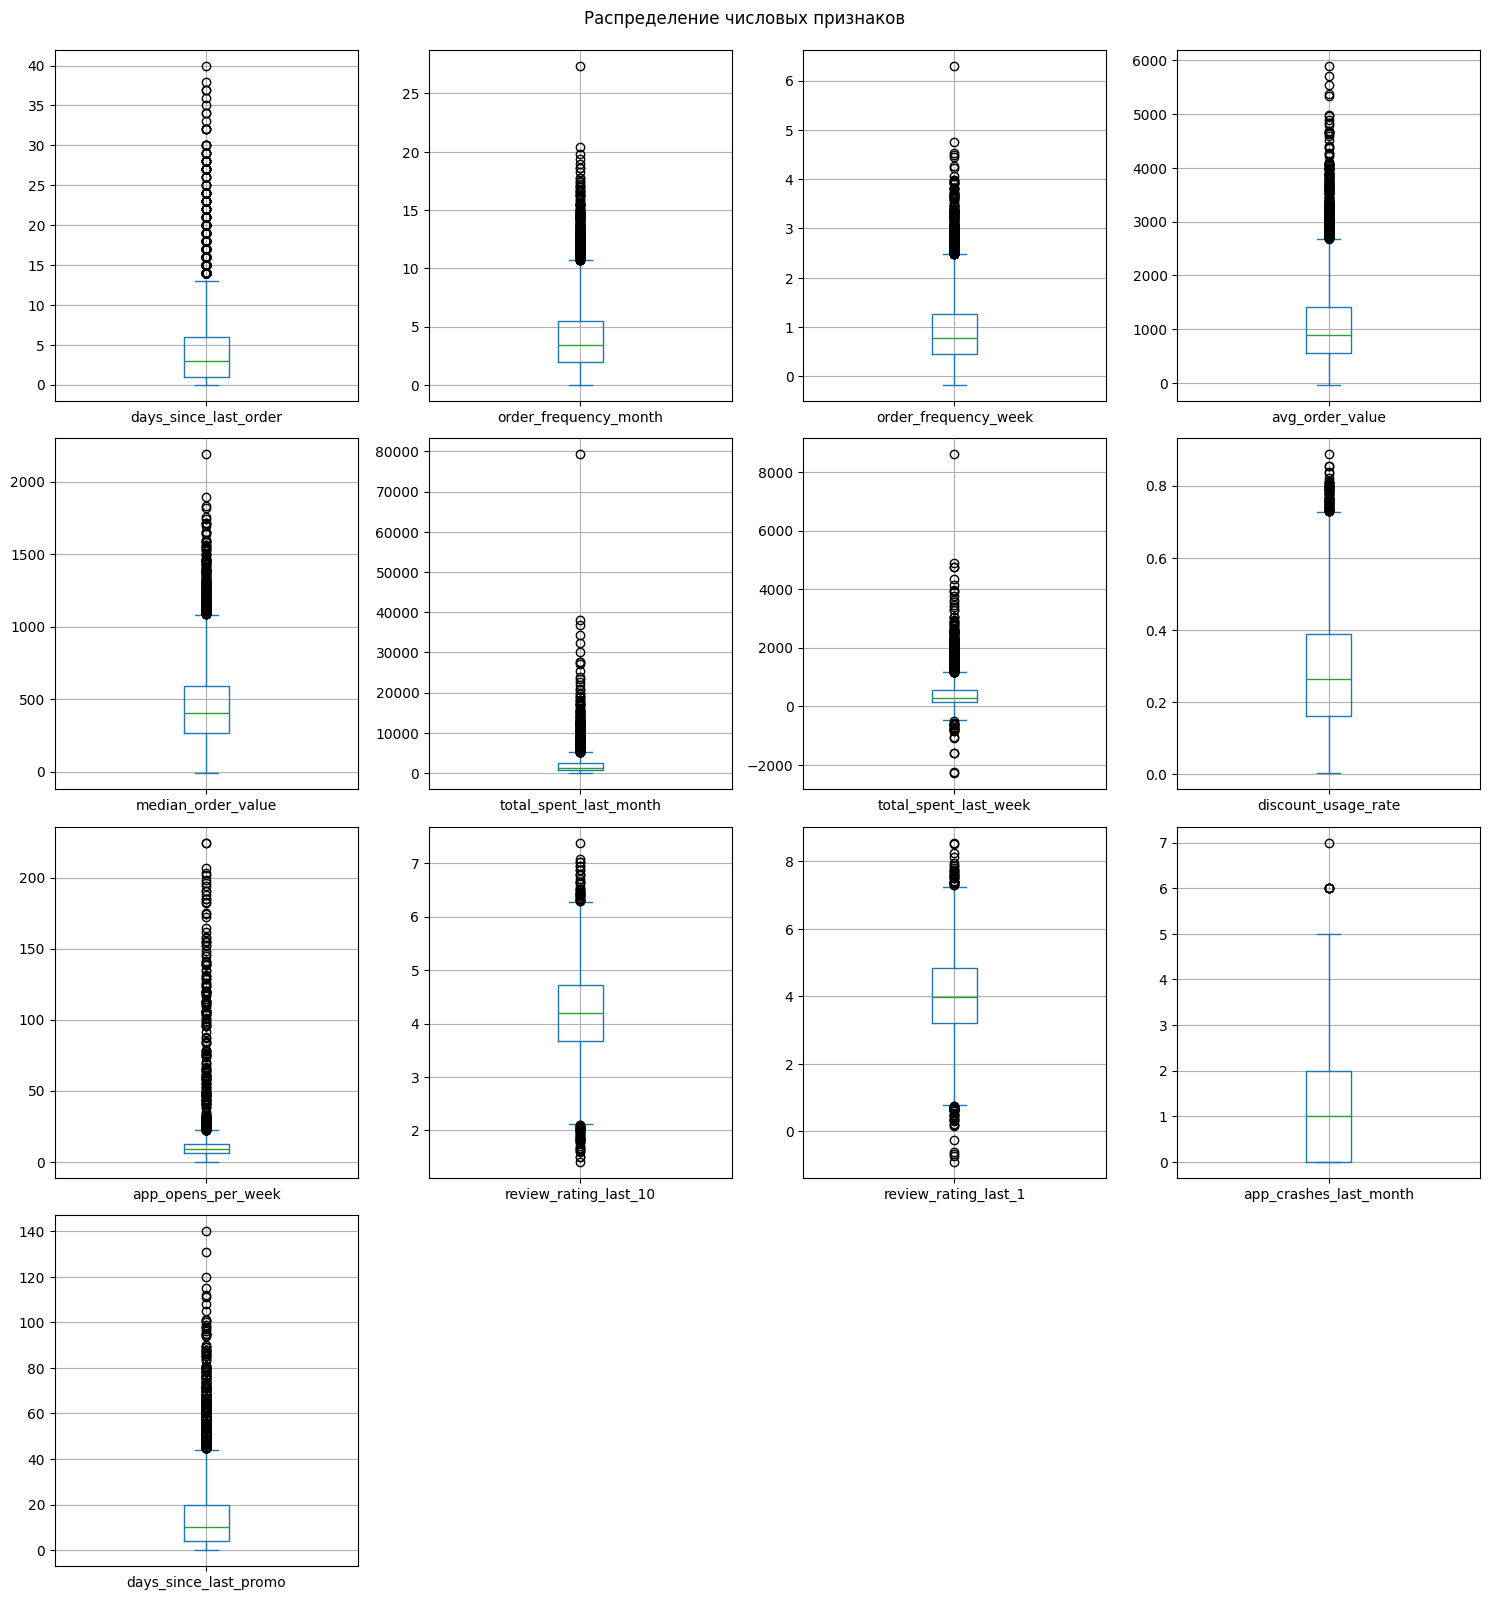

In [38]:
df[num_features].plot.box(
    subplots=True,
    figsize=(15, 20),
    layout=(5, 4),
    showfliers=True,
    sharey=False,
    grid=True
)

plt.tight_layout()
plt.suptitle('Распределение числовых признаков')
plt.subplots_adjust(top=0.96)

plt.show()

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10036 entries, 0 to 10035
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   days_since_last_order   9134 non-null   Int8   
 1   order_frequency_month   9454 non-null   float64
 2   order_frequency_week    9659 non-null   float64
 3   avg_order_value         9476 non-null   float64
 4   median_order_value      9232 non-null   float64
 5   total_spent_last_month  9748 non-null   float64
 6   total_spent_last_week   9120 non-null   float64
 7   discount_usage_rate     9653 non-null   float64
 8   seasonal_menu_tried     9086 non-null   Int8   
 9   subscription_status     9144 non-null   object 
 10  app_opens_per_week      9179 non-null   float64
 11  notifications_enabled   9522 non-null   Int8   
 12  review_rating_last_10   9362 non-null   float64
 13  review_rating_last_1    9214 non-null   float64
 14  app_crashes_last_month  9342 non-null   Int8   
 

- Признаки `review_rating_last_10`, `review_rating_last_1` имеют симметричное распределение.
- Все остальные признаки имеют правое асимметричное распределение.
- В **6 столбцах**: `order_frequency_week`,	`avg_order_value`, `median_order_value`, `total_spent_last_month`, `total_spent_last_week`,	`review_rating_last_1`, присутствуют **аномальные** значения **ниже 0**. Это **ошибочные выбросы**.
- **Высокие** значения можно отнести к **реальным выбросам**.

**Стратегия обработки выбросов**
- Выбросы в поведенческих данных часто несут полезную информацию.
- Преобразования позволяют сохранить эту информацию и сделать её более удобной для модели.
- **Замена значений**:
    - **ближайшим корректным значением 0** аномальных значений ниже 0;
    - использовать преобразование **квадратным корнем** для высоких аномальных значений.   

#### Выводы
- В данных содержатся **ошибочные и реальные выбросы**.
- **Стратегия обработки выбросов**:
    - аномальные значения **ниже 0** - замена значений ближайшим корректным значением 0;
    - высокие аномальные значения - использовать преобразование **квадратным корнем** для более равномерного распределения.

---
### 5.7. Корреляция

- Рассчитаем коэффициент корреляции **phi_k** между признаками и целевой переменной `weight`

In [40]:
corr_matrix = df.phik_matrix()
corr_matrix

interval columns not set, guessing: ['days_since_last_order', 'order_frequency_month', 'order_frequency_week', 'avg_order_value', 'median_order_value', 'total_spent_last_month', 'total_spent_last_week', 'discount_usage_rate', 'seasonal_menu_tried', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo', 'churn']


,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,churn
days_since_last_order,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.043594,0.000000,0.000000,0.000000,0.000000,0.067620,0.000000,0.000000,0.000000
order_frequency_month,0.000000,1.000000,0.990059,0.000000,0.098830,0.421371,0.480493,0.000000,0.027959,0.000000,0.203096,0.000000,0.007878,0.000000,0.024616,0.000000,0.080403
order_frequency_week,0.000000,0.990059,1.000000,0.000000,0.095004,0.387853,0.479991,0.021613,0.000000,0.000000,0.181983,0.010243,0.000000,0.000000,0.000000,0.000000,0.083562
avg_order_value,0.000000,0.000000,0.000000,1.000000,0.892262,0.168906,0.286709,0.024241,0.000000,0.000000,0.000000,0.000000,0.035753,0.000000,0.028574,0.051581,0.021916
median_order_value,0.000000,0.098830,0.095004,0.892262,1.000000,0.443867,0.691597,0.027087,0.015571,0.038107,0.016533,0.031287,0.000000,0.000000,0.000000,0.000000,0.000000
total_spent_last_month,0.000000,0.421371,0.387853,0.168906,0.443867,1.000000,0.598378,0.023336,0.000000,0.016383,0.468501,0.000000,0.000000,0.000000,0.000000,0.000000,0.031545
total_spent_last_week,0.000000,0.480493,0.479991,0.286709,0.691597,0.598378,1.000000,0.000000,0.000000,0.018083,0.091027,0.002685,0.000000,0.000000,0.000000,0.000000,0.051935
discount_usage_rate,0.000000,0.000000,0.021613,0.024241,0.027087,0.023336,0.000000,1.000000,0.019817,0.010049,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.023653
seasonal_menu_tried,0.043594,0.027959,0.000000,0.000000,0.015571,0.000000,0.000000,0.019817,1.000000,0.018776,0.000000,0.031580,0.000000,0.032674,0.017493,0.036247,0.000000
subscription_status,0.000000,0.000000,0.000000,0.000000,0.038107,0.016383,0.018083,0.010049,0.018776,1.000000,0.212413,0.000000,0.035742,0.000000,0.000000,0.000000,0.105209


Посчитайте корреляции между признаками. Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.

In [41]:
corr_matrix = df.phik_matrix()
heat_map = corr_matrix.loc[corr_matrix.index != 'churn'][['churn']].sort_values(by='churn', ascending=False)
heat_map

interval columns not set, guessing: ['days_since_last_order', 'order_frequency_month', 'order_frequency_week', 'avg_order_value', 'median_order_value', 'total_spent_last_month', 'total_spent_last_week', 'discount_usage_rate', 'seasonal_menu_tried', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo', 'churn']


,churn
app_crashes_last_month,0.853398
app_opens_per_week,0.116229
subscription_status,0.105209
order_frequency_week,0.083562
order_frequency_month,0.080403
total_spent_last_week,0.051935
total_spent_last_month,0.031545
review_rating_last_10,0.025842
discount_usage_rate,0.023653
avg_order_value,0.021916


- Визуализируем результат корреляции с помощью тепловой карты 

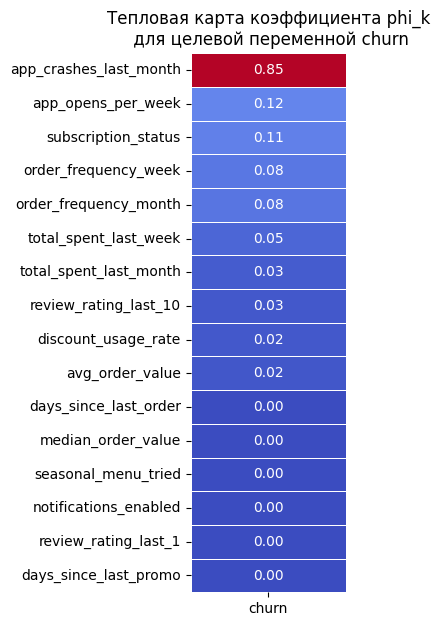

In [42]:
plt.figure(figsize=(2, 7))

sns.heatmap(
    heat_map,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    cbar=False
)

plt.title('Тепловая карта коэффициента phi_k\n для целевой переменной churn')

plt.show()

- Удаляем следующие признаки:
    - `order_frequency_month` - корреляция = 0.99 с признаком `order_frequency_week`;	
    - остальные признаки: корреляция = 0 целевой переменной `churn`

In [43]:
columns_to_drop = ['days_since_last_order', 'median_order_value', 'seasonal_menu_tried', 'notifications_enabled', 'review_rating_last_1', 'days_since_last_promo', 'order_frequency_month']

In [44]:
df = df.drop(columns=columns_to_drop)

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10036 entries, 0 to 10035
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_frequency_week    9659 non-null   float64
 1   avg_order_value         9476 non-null   float64
 2   total_spent_last_month  9748 non-null   float64
 3   total_spent_last_week   9120 non-null   float64
 4   discount_usage_rate     9653 non-null   float64
 5   subscription_status     9144 non-null   object 
 6   app_opens_per_week      9179 non-null   float64
 7   review_rating_last_10   9362 non-null   float64
 8   app_crashes_last_month  9342 non-null   Int8   
 9   churn                   10036 non-null  Int8   
dtypes: Int8(2), float64(7), object(1)
memory usage: 666.6+ KB


In [46]:
del_cols = cols_df - df.shape[1] 
print(f'Всего удалено столбцов: {del_cols}')

Всего удалено столбцов: 7


#### Выводы
- **Удалили 7 признаков**:
    - `order_frequency_month`:
        - корреляция = 0.99 с признаком `order_frequency_week`;
    - `days_since_last_order`, `median_order_value`, `seasonal_menu_tried`, `notifications_enabled`, `review_rating_last_1`, `days_since_last_promo;
        - корреляция = 0 с признаком `order_frequency_week` с целевой переменной `churn`.
- Наиболее **важные** признаки:
    - `app_crashes_last_month` - **0.85**.
- **Значимые** признаки: 
    - `app_opens_per_week` - **0.12**;
    - `subscription_status` - **0.11**;
    - `order_frequency_week` - **0.08**
- Датафрейм `df` содержит **10036 строк и 10 столбцов**.

---
## 5.8. Выводы
1. **Дисбаланс классов**
- В данных наблюдается **сильный дисбаланс** классов.
- Целевая переменная `churn` распределена крайне неравномерно:
    - **94%** клиентов остаются с сервисом - **класс 0**;
    - **6%** клиентов уходят - **класс 1**.
- При построении модели необходимо использовать метрики, нечувствительные к дисбалансу.
2. **Качество данных и их подготовка**
- **Пропущенные значения**:
    - в датасете присутствует **от 2.8% до 9.5%** пропусков по различным признакам;
    - стратегия заполнения:
        - **среднее** - для числовых;
        - **'none'** - для категориальных.
- **Дубликаты**:
    - в исходных данных обнаружено **3.96%** дубликатов - **414 строк**.
    - все дубликаты **удалены**.
- **Выбросы**:
    - В данных присутствуют **аномально высокие** значения (реальные выбросы) и **аномально низкие** значения (ошибочные выбросы).
    - **Стратегия обработки**:
        - аномальные значения **ниже 0** - замена значений ближайшим корректным значением 0;
        - высокие аномальные значения - использовать преобразование **квадратным корнем** для более равномерного распределения.
3. **Оптимизация признакового пространства**
- **Удаление признаков**
    - **Всего** удалено **17 признаков**:
        - `user_id`, `geo_location` - технические идентификаторы;
        - `last_coffee_type`, `preferred_roast`, `milk_preference`, `coffee_bean_origin`, `last_drink_size`, `coffee_preference_change` - вкусовые предпочтения, не информативны;
        - `seasons`- признак не информативен, поcкольку данные агрегированы за последние 4 недели;
        - `phone_type` - количество сбоев приложения (`app_crashes_last_month`) распределено равномерно по платформам, признак не информативен;
        - `order_frequency_month` - почти идеальной корреляции с `order_frequency_week`;
        - `days_since_last_order`, `median_order_value`, `seasonal_menu_tried`, `notifications_enabled`, `review_rating_last_1`, `days_since_last_promo`- нулевая корреляция с целевой переменной `churn`.
- **Обработка категориальных признаков**
    - метод **Target Encoding** - для признака `subscription_status`;
    - позволит преобразовать категории в числовые значения, отражающие их связь с оттоком.
4. **Ключевые факторы оттока**
- **Самый важный признак**: `app_crashes_last_month`- корреляция **0.85**;
    - стабильность приложения — критически важный фактор для удержания клиентов.
- **Значимые признаки**:
    - `app_opens_per_week` - корреляция **0.12**: активность в приложении;
    - `subscription_status` - корреляция **0.11**: статус подписки;
    - `order_frequency_week` - корреляция **0.08**: частота заказов.
5. **Итог**
- Удалили **414 строк и 17 столбцов**.
- Датасет `df` содержит **10036 строк и 10 столбцов**.

---
## 6. Предобработка данных <a id='preprocess'></a>
### 6.1. Разделение данных на выборки

-  Разделяем данные на **train и test** в соотношении **80/20**

In [47]:
X = df.drop(columns=['churn'])
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, stratify=y, random_state=RANDOM_STATE
)

print(f'train: {X_train.shape} {y_train.shape}')
print(f'test: {X_test.shape} {y_test.shape}')

train: (8028, 9) (8028,)
test: (2008, 9) (2008,)


#### Выводы
Разделили данные на выборки:
- **обучающая - 80%**: (8028, 7) (8028,)
- **тестовая - 20%**: (2008, 7) (2008,)

---
### 6.2. Создание пайплайна

- Создадим списки списки числовых и категориальных признаков:

In [48]:
num_features = ['order_frequency_week','avg_order_value', 'total_spent_last_month', 'total_spent_last_week', 
                'discount_usage_rate', 'app_opens_per_week', 'review_rating_last_10', 'app_crashes_last_month']
cat_features = ['subscription_status']

- Напишем функцию для создания пайплайна

In [49]:
def clip_outliers(X):
    return np.clip(X, a_min=0, a_max=None)

def create_pipeline(**kwargs):

    strategy='mean'
    method='standard'
    
    num_pipeline = Pipeline([
        ('clipper', FunctionTransformer(clip_outliers, validate=False, feature_names_out='one-to-one')),
        ('imputer', SimpleImputer(strategy=strategy))
    ])

    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='none')),
        ('encoder', TargetEncoder())
    ])
 
    preprocessor = ColumnTransformer([
        ('num_features', num_pipeline, num_features),
        ('cat_features', cat_pipeline, cat_features)
    ])

    if method == 'minmax':
        scaler = MinMaxScaler()
    else:
        scaler = StandardScaler()

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('scaler', scaler),
        ('classifier', LogisticRegression(random_state=RANDOM_STATE, **kwargs))
        
    ])

    return pipeline

In [50]:
pipeline = create_pipeline()
pipeline

,steps,"[('preprocessor', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_features', ...), ('cat_features', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


---
## 7. Обучение модели <a id='train'></a>

- Напишем функцию для вызова автоматической кросс-валидации и сохранения результатов:

In [51]:
summary = []
score_means = {}

def eval_model(X, y, pipeline, final=0): 
    
    cv_results = cross_validate(
        estimator=pipeline,
        X=X,
        y=y,
        scoring=scoring,
        cv=kfold
    )

    log_loss = -cv_results['test_neg_log_loss'].mean()
    precision = cv_results['test_precision'].mean()
    recall = cv_results['test_recall'].mean()
    pr_auc = cv_results['test_average_precision'].mean()

    model = pipeline.named_steps['classifier']

    print("Результаты модели (средние значения):")
    print("-" * 70)
    print(f'Log_loss: {log_loss:.3f}')
    print(f'Precision: {precision:.3f}')
    print(f'Recall: {recall:.3f}')
    print(f'PR_AUC: {pr_auc:.3f}')
    

    summary.append({
        'Название': pipeline.named_steps['classifier'],
        'Scaler': pipeline.named_steps['scaler'],
        'Log_loss': log_loss,
        'Precision': precision,
        'Recall': recall,
        'PR_AUC': pr_auc
    })

    if final:
        cv_results = {
            'log_loss': log_loss,
            'precision': precision,
            'recall': recall,
            'pr_auc': pr_auc
        }
        return cv_results

- Определим метрики для оценки качества

In [52]:
scoring = ['neg_log_loss', 'precision', 'recall', 'average_precision']

- Настроим кросс-валидацию

In [53]:
kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

- Обучим базовую модель **LogisticRegression** и рассчитаем метрики

In [54]:
eval_model(X_train, y_train, pipeline)

Результаты модели (средние значения):
----------------------------------------------------------------------
Log_loss: 0.119
Precision: 0.818
Recall: 0.432
PR_AUC: 0.684


In [55]:
sum_df = pd.DataFrame(summary)
sum_df.style.format({
    'Log_loss': '{:.3f}',
    'Precision': '{:.3f}', 
    'Recall': '{:.3f}',
    'PR_AUC': '{:.3f}'
})

,Название,Scaler,Log_loss,Precision,Recall,PR_AUC
0,LogisticRegression(random_state=42),StandardScaler(),0.119,0.818,0.432,0.684


### Выводы
- **PR-AUC: 0.684**
    - Хороший результат для задачи с несбалансированными классами.
    - Модель в целом корректно ранжирует клиентов (уходящим ставит более высокие баллы вероятности).
- **Precision: 0.818**
    - Высокий показатель.
    - Когда модель предсказывает, что клиент уйдет, она оказывается права в **81.8%** случаев.
- **Recall: 0.432**
    - Довольно низкий показатель.
    - Модель смогла найти и правильно предсказать уход только для **43.2%** клиентов, которые на самом деле собирались уйти.

Анализ метрик показывает, что модель **LogisticRegression**: 
- демонстрирует **хорошее, но несбалансированное** качество;
- есть существенный **дисбаланс между точностью и полнотой** - высокий Precision при низком Recall.

---
## 8. Создание новых признаков <a id='new_features'></a>

- Добавим новые признаки, которые могут улучшить качество модели:
    - **преобразование квадратным корнем**: `avg_order_value_sqrt`, `app_opens_per_week_sqrt`;
    - **возведение в квадрат**: `app_crashes_last_month_sqr`, `review_rating_last_10`.

In [56]:
group1 = ['avg_order_value', 'app_opens_per_week']
group2 = ['app_crashes_last_month', 'review_rating_last_10']

In [57]:
def create_enhanced_features(X, group1, group2):
    X_enhanced = X.copy()

    for feature in group1:
        X_enhanced[f'{feature}_sqrt'] = np.sqrt(X[feature].clip(lower=0))

    for feature in group2:
        X_enhanced[f'{feature}_sqr'] = X[feature] ** 2

    columns_to_drop = group1 + group2

    X_enhanced = X_enhanced.drop(columns=columns_to_drop)
    
    return X_enhanced

In [58]:
X_train_enhanced = create_enhanced_features(X_train, group1, group2)

In [59]:
X_train_enhanced.info()

<class 'pandas.DataFrame'>
Index: 8028 entries, 759 to 3416
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   order_frequency_week        7726 non-null   float64
 1   total_spent_last_month      7785 non-null   float64
 2   total_spent_last_week       7281 non-null   float64
 3   discount_usage_rate         7712 non-null   float64
 4   subscription_status         7315 non-null   object 
 5   avg_order_value_sqrt        7575 non-null   float64
 6   app_opens_per_week_sqrt     7348 non-null   float64
 7   app_crashes_last_month_sqr  7468 non-null   Int8   
 8   review_rating_last_10_sqr   7491 non-null   float64
dtypes: Int8(1), float64(7), object(1)
memory usage: 580.1+ KB


In [60]:
print(f'Количество признаков: {X_train.shape[1]}(старые) → {X_train_enhanced.shape[1]}(новые)')

Количество признаков: 9(старые) → 9(новые)


- Обновим список с числовыми признаками

In [61]:
num_features = X_train_enhanced.columns.to_list()
num_features.remove('subscription_status')
num_features

['order_frequency_week',
 'total_spent_last_month',
 'total_spent_last_week',
 'discount_usage_rate',
 'avg_order_value_sqrt',
 'app_opens_per_week_sqrt',
 'app_crashes_last_month_sqr',
 'review_rating_last_10_sqr']

- Обновим пайплайн для работы с новыми признаками и проведём повторную кросс-валидацию

In [62]:
pipeline = create_pipeline()
eval_model(X_train_enhanced, y_train, pipeline)
pipeline

Результаты модели (средние значения):
----------------------------------------------------------------------
Log_loss: 0.110
Precision: 0.814
Recall: 0.471
PR_AUC: 0.710


,steps,"[('preprocessor', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_features', ...), ('cat_features', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [63]:
sum_df = pd.DataFrame(summary)
sum_df.assign(
    Изм_Log_loss=lambda x: (x['Log_loss'] - sum_df.iloc[0, 2]),
    Изм_Precision=lambda x: (x['Precision'] - sum_df.iloc[0, 3]),
    Изм_Recall=lambda x: (x['Recall'] - sum_df.iloc[0, 4]),
    Изм_PR_AUC=lambda x: (x['PR_AUC'] - sum_df.iloc[0, 5])
) \
    .reindex(columns=['Название', 'Scaler', 'Log_loss', 'Изм_Log_loss', 'Precision', 'Изм_Precision', 'Recall', 'Изм_Recall', 'PR_AUC', 'Изм_PR_AUC']) \
    .style.format({
        'Log_loss': '{:.3f}',
        'Precision': '{:.3f}', 
        'Recall': '{:.3f}',
        'PR_AUC': '{:.3f}',
        'Изм_Log_loss': '{:.3f}',
        'Изм_Precision': '{:.3f}', 
        'Изм_Recall': '{:.3f}',
        'Изм_PR_AUC': '{:.3f}'
    })

,Название,Scaler,Log_loss,Изм_Log_loss,Precision,Изм_Precision,Recall,Изм_Recall,PR_AUC,Изм_PR_AUC
0,LogisticRegression(random_state=42),StandardScaler(),0.119,0.000,0.818,0.000,0.432,0.000,0.684,0.000
1,LogisticRegression(random_state=42),StandardScaler(),0.110,-0.009,0.814,-0.003,0.471,0.039,0.710,0.026


- Обучим пайплайн

In [64]:
pipeline.fit(X_train_enhanced, y_train)

,steps,"[('preprocessor', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_features', ...), ('cat_features', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [65]:
model = pipeline.named_steps['classifier']

In [66]:
model.coef_

array([[ 0.49411298, -0.51078116,  0.39054199, -0.01733879,  0.05673279,
         0.52941931,  1.88337007, -0.04248985,  0.29528197]])

- Выявим значимые признаки и удалим лишние

In [67]:
cols_pr = pipeline[:-1].get_feature_names_out()
cols = [name.replace('num_features__', '') for name in cols_pr[:-1]] + ['subscription_status']

In [68]:
pd.DataFrame(
    model.coef_.T, 
    index=cols,
    columns=['Коэффициент']
).sort_values(by='Коэффициент', key=abs, ascending=False) \
.style.format({'Коэффициент': '{:.3f}'})

,Коэффициент
app_crashes_last_month_sqr,1.883
app_opens_per_week_sqrt,0.529
total_spent_last_month,-0.511
order_frequency_week,0.494
total_spent_last_week,0.391
subscription_status,0.295
avg_order_value_sqrt,0.057
review_rating_last_10_sqr,-0.042
discount_usage_rate,-0.017


**Интерпретация коэффициентов**
- `app_crashes_last_month_sqr` - **1.883**:
    - **самый важный коэффициент**;
    - сильнейший драйвер оттока;
    - квадратичная зависимость подчеркивает, что каждый новый сбой приложения наносит всё больший урон лояльности пользователя;
- `app_opens_per_week_sqrt` - **0.529**:
    - частые открытия приложения могут быть признаком того, что пользователь постоянно сталкивается с проблемами;
    - такая вынужденная активность коррелирует с высоким риском ухода;
- `total_spent_last_month` - **-0.511**:
    - увеличение трат клиента за последний месяц снижает вероятность его ухода;
- `order_frequency_week` - **0.494**:
    - пользователи, которые чаще заказывают в течение недели, более склонны к уходу;
- `subscription_status` - **0.295**:
    - наличие подписки увеличивает вероятность ухода;
- `avg_order_value_sqrt` - **0.057**, `review_rating_last_10_sqr` - **-0.042**, `discount_usage_rate` - **-0.017**:
    - признаки имеют крайне низкое абсолютное значение коэффициента;
    - их влияние на прогноз ничтожно мало.

Необходимо **удалить следующие признаки**:
- `review_rating_last_10_sqr`;
- `avg_order_value_sqrt`;
- `discount_usage_rate`.

Удаление этих трех признаков упростит модель, сделает её более быстрой и устойчивой к переобучению, при этом практически не повлияв на качество прогноза.

- Удаляем неинформативные признаки:

In [69]:
X_train_enhanced = X_train_enhanced.drop(columns=['avg_order_value_sqrt', 'review_rating_last_10_sqr', 'discount_usage_rate'])
X_train_enhanced.info()

<class 'pandas.DataFrame'>
Index: 8028 entries, 759 to 3416
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   order_frequency_week        7726 non-null   float64
 1   total_spent_last_month      7785 non-null   float64
 2   total_spent_last_week       7281 non-null   float64
 3   subscription_status         7315 non-null   object 
 4   app_opens_per_week_sqrt     7348 non-null   float64
 5   app_crashes_last_month_sqr  7468 non-null   Int8   
dtypes: Int8(1), float64(4), object(1)
memory usage: 392.0+ KB


- Обновим список числовых признаков:

In [70]:
num_features = ['order_frequency_week', 'total_spent_last_month', 'total_spent_last_week', 'app_opens_per_week_sqrt', 'app_crashes_last_month_sqr']

## Выводы
- Добавили **4** новых признака:
    - **преобразование квадратным корнем**: `avg_order_value_sqrt`, `app_opens_per_week_sqrt`;
    - **возведение в квадрат**: `app_crashes_last_month_sqr`, `review_rating_last_10`.
    - метрики модели **улучшились**:
        - **PR-AUC: 0.710 - + 0.026**;
        - **Precision: 0.814 - -0.003**;
        - **Recall: 471 - + 0.039**.
- **Наиболее значимые** коэффициенты:
    - `app_crashes_last_month_sqr` - **1.883**.
- **Удалили 3 наименее значимых коэффициента**:
    - `avg_order_value_sqrt`: **0.057**;
    - `review_rating_last_10_sqr`: **- 0.042**;
    - `discount_usage_rate`: **- 0.017**.
- Обучающая выборка содержит **6 признаков**:
    - `order_frequency_week`;
    - `subscription_status`;
    - `total_spent_last_month`;
    - `total_spent_last_week`;  
    - `app_opens_per_week_sqrt`;
    - `app_crashes_last_month_sqr`.

---
## 9. Эксперименты с гиперпараметрами <a id='experiments'></a>

### 9.1. Проведение экспериментов
- **Коэффициент регуляризации - C**:
    - значения для теста: **[0.001, 0.01, 0.1, 1.0, 10, 100]**.
- **Тип регуляризации - penalty**:
    - значения для теста: **['l1', 'l2', 'l2'], ['saga', 'lbfgs', 'saga']**.

In [71]:
summary = []

- Найдём оптимальный **коэффициент регуляризации - C**:

In [72]:
for c in [0.001, 0.01, 0.1, 1.0, 10, 100]:
    pipeline = create_pipeline(C=c)
    print(f'\nКоэффициент регуляризации C = {c}')
    eval_model(X_train_enhanced, y_train, pipeline)


Коэффициент регуляризации C = 0.001
Результаты модели (средние значения):
----------------------------------------------------------------------
Log_loss: 0.158
Precision: 1.000
Recall: 0.056
PR_AUC: 0.702

Коэффициент регуляризации C = 0.01
Результаты модели (средние значения):
----------------------------------------------------------------------
Log_loss: 0.116
Precision: 0.934
Recall: 0.342
PR_AUC: 0.708

Коэффициент регуляризации C = 0.1
Результаты модели (средние значения):
----------------------------------------------------------------------
Log_loss: 0.110
Precision: 0.834
Recall: 0.450
PR_AUC: 0.711

Коэффициент регуляризации C = 1.0
Результаты модели (средние значения):
----------------------------------------------------------------------
Log_loss: 0.109
Precision: 0.817
Recall: 0.469
PR_AUC: 0.712

Коэффициент регуляризации C = 10
Результаты модели (средние значения):
----------------------------------------------------------------------
Log_loss: 0.109
Precision: 0.807
R

- Проверим, какой **тип регуляризации - penalty** дает лучший результат:

In [73]:
for penalty, solver in zip(['l1', 'l2', 'l2', 'elasticnet'], ['saga', 'lbfgs', 'saga', 'saga']):
    print(f'\nТип регуляризации penalty = {penalty}, solver = {solver}')
    if penalty == 'elasticnet':
        pipeline = create_pipeline(penalty=penalty, solver=solver, l1_ratio=0.5)
    else:
        pipeline = create_pipeline(penalty=penalty, solver=solver)
    eval_model(X_train_enhanced, y_train, pipeline)


Тип регуляризации penalty = l1, solver = saga
Результаты модели (средние значения):
----------------------------------------------------------------------
Log_loss: 0.109
Precision: 0.817
Recall: 0.469
PR_AUC: 0.712

Тип регуляризации penalty = l2, solver = lbfgs
Результаты модели (средние значения):
----------------------------------------------------------------------
Log_loss: 0.109
Precision: 0.817
Recall: 0.469
PR_AUC: 0.712

Тип регуляризации penalty = l2, solver = saga
Результаты модели (средние значения):
----------------------------------------------------------------------
Log_loss: 0.109
Precision: 0.817
Recall: 0.469
PR_AUC: 0.711

Тип регуляризации penalty = elasticnet, solver = saga
Результаты модели (средние значения):
----------------------------------------------------------------------
Log_loss: 0.109
Precision: 0.817
Recall: 0.469
PR_AUC: 0.711


---
### 9.2. Выбор лучшей модели

- Выведем итоговую таблицу с результатами экспериментов

In [74]:
sum_df = pd.DataFrame(summary)
sum_df.style.format({
    'Log_loss': '{:.3f}',
    'Precision': '{:.3f}', 
    'Recall': '{:.3f}',
    'PR_AUC': '{:.3f}'
})

,Название,Scaler,Log_loss,Precision,Recall,PR_AUC
0,"LogisticRegression(C=0.001, random_state=42)",StandardScaler(),0.158,1.000,0.056,0.702
1,"LogisticRegression(C=0.01, random_state=42)",StandardScaler(),0.116,0.934,0.342,0.708
2,"LogisticRegression(C=0.1, random_state=42)",StandardScaler(),0.110,0.834,0.450,0.711
3,LogisticRegression(random_state=42),StandardScaler(),0.109,0.817,0.469,0.712
4,"LogisticRegression(C=10, random_state=42)",StandardScaler(),0.109,0.807,0.469,0.711
5,"LogisticRegression(C=100, random_state=42)",StandardScaler(),0.109,0.808,0.471,0.712
6,"LogisticRegression(penalty='l1', random_state=42, solver='saga')",StandardScaler(),0.109,0.817,0.469,0.712
7,LogisticRegression(random_state=42),StandardScaler(),0.109,0.817,0.469,0.712
8,"LogisticRegression(random_state=42, solver='saga')",StandardScaler(),0.109,0.817,0.469,0.711
9,"LogisticRegression(l1_ratio=0.5, penalty='elasticnet', random_state=42, solver='saga')",StandardScaler(),0.109,0.817,0.469,0.711


- **Конфигурация** лучшей модели

In [75]:
best_config = {
    'C': 1.0,
    'penalty': 'l2',
    'solver': 'lbfgs'
}

In [76]:
pipeline = create_pipeline(**best_config)
best_results = eval_model(X_train_enhanced, y_train, pipeline, final=1)

Результаты модели (средние значения):
----------------------------------------------------------------------
Log_loss: 0.109
Precision: 0.817
Recall: 0.469
PR_AUC: 0.712


- **Лучшая модель** по результатам экспериментов

In [77]:
pipeline.named_steps['classifier']

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Выводы
- Провели систематический **перебор гиперпараметров** для LogisticRegression, выполнили кросс-валидацию для каждой конфигурации:
    - **коэффициент регуляризации - C**: [0.001, 0.01, 0.1, 1.0, 10, 100].
    - **тип регуляризации - penalty**: ['l1', 'l2', 'l2'], ['saga', 'lbfgs', 'saga'].
- Составили итоговую таблицу с результатами экспериментов.
- **Лучшая модель** по результатам экспериментов:
    - метрики модели:
        - **PR_AUC: 0.712**;
        - **Precision: 0.817**;
        - **Recall: 0.469**;
    - конфигурация модели:
        - **C: 1.0**,
        - **penalty: l2**,
        - **solver': lbfgs**.

---
## 10. Подготовка финальной модели <a id='final'></a>

- Оптимальный набор признаков и лучшая конфигурация гиперпараметров модели

In [78]:
num_features = ['order_frequency_week', 'total_spent_last_month', 'total_spent_last_week', 'app_opens_per_week_sqrt', 'app_crashes_last_month_sqr']
cat_features = ['subscription_status']
best_config = {
    'C': 1.0,
    'penalty': 'l2',
    'solver': 'lbfgs'
}

- Обучим модель на всех данных для кросс-валидаци

In [79]:
pipeline = create_pipeline(**best_config)
pipeline.fit(X_train_enhanced, y_train)

,steps,"[('preprocessor', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_features', ...), ('cat_features', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


- Создадим расширенный набор признаков для тестовых данных

In [80]:
X_test_enhanced = create_enhanced_features(X_test, group1, group2)
X_test_enhanced = X_test_enhanced[num_features + cat_features]

In [81]:
X_test_enhanced.info()

<class 'pandas.DataFrame'>
Index: 2008 entries, 959 to 6910
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   order_frequency_week        1933 non-null   float64
 1   total_spent_last_month      1963 non-null   float64
 2   total_spent_last_week       1839 non-null   float64
 3   app_opens_per_week_sqrt     1831 non-null   float64
 4   app_crashes_last_month_sqr  1874 non-null   Int8   
 5   subscription_status         1829 non-null   object 
dtypes: Int8(1), float64(4), object(1)
memory usage: 98.0+ KB


- Получим предсказания вероятностей и классов

In [82]:
y_test_pred_proba = pipeline.predict_proba(X_test_enhanced)[:, 1]
y_test_pred = pipeline.predict(X_test_enhanced)

- Рассчитаем финальные метрики

In [83]:
final_log_loss = log_loss(y_test, y_test_pred_proba)
final_precision = precision_score(y_test, y_test_pred)
final_recall = recall_score(y_test, y_test_pred)
final_pr_auc = average_precision_score(y_test, y_test_pred_proba)

print('\nФинальные результаты на тестовой выборке')
print("-" * 70)
print(f'Log_loss: {final_log_loss:.3f}')
print(f'Precision: {final_precision:.3f}')
print(f'Recall: {final_recall:.3f}')
print(f'PR_AUC: {final_pr_auc:.3f}')


Финальные результаты на тестовой выборке
----------------------------------------------------------------------
Log_loss: 0.120
Precision: 0.720
Recall: 0.492
PR_AUC: 0.666


- Сравним финальные результаты с кросс-валидацией:

In [84]:
print("\nСравнение с кросс-валидацией:")
print("-" * 50)
print(f"{'Метрика':<12} {'CV':<12} {'Test':<12} {'Разница':<10}")
print("-" * 50)

test_results_final = {
    'log_loss': final_log_loss,
    'precision': final_precision,
    'recall': final_recall,
    'pr_auc': final_pr_auc
}

for metric in ['log_loss', 'precision', 'recall', 'pr_auc']:
    cv_mean = best_results[metric]
    test_score = test_results_final[metric]
    diff = test_score - cv_mean

    print(f"{metric.upper():<12} {cv_mean:<12.3f} {test_score:<12.3f} {diff:+.3f}")


Сравнение с кросс-валидацией:
--------------------------------------------------
Метрика      CV           Test         Разница   
--------------------------------------------------
LOG_LOSS     0.109        0.120        +0.011
PRECISION    0.817        0.720        -0.098
RECALL       0.469        0.492        +0.023
PR_AUC       0.712        0.666        -0.046


## Выводы
- В целом, **результаты** модели на тестовой выборке **близки к результатам** кросс-валидации:
- **Сравнение результатов** кросс-валидации и тестовой выборки:
    - модель является стабильной и **не переобучена**;
    - разброс между метриками невелик, что говорит о **способности модели к обобщению** на новых данных;
    - наблюдается характерный сдвиг в поведении модели: на тестовой выборке модель стала работать более консервативно.

## 11. Отчёт о проделанной работе <a id='resume'></a>
### 11.1. Загрузка данных
- Загрузили данные из датасета `coffee_churn_dataset.csv`: **10450 строк и 27 столбцов**.
- Привели столбцы к соответствующим описанию данных типам и оптимизировали размерность числовых столбцов.
- Пропуски содержатся во всех столбцах, кроме `user_id` и `churn`.
### 11.2. Исследовательский анализ данных
- В данных наблюдается **сильный дисбаланс** классов.
    - **94%** клиентов остаются с сервисом - **класс 0**;
    - **6%** клиентов уходят - **класс 1**.
- **Удалили 9 неинформативных признаков**: `user_id`, `last_coffee_type`, `preferred_roast`, `milk_preference`, `coffee_bean_origin`, `last_drink_size`, `geo_location`, `coffee_preference_change`, `seasons`.
- В датасете присутствует **от 2.8% до 9.5%** пропусков по различным признакам. **Все пропуски оставили как есть**.
- Определили **стратегию заполнения пропусков**:
    - категориальные признаки - значением **'none'**.
    - числовые признаки - **средним значением** соответствующего признака.
- Проанализировали **категориальные** признаки:
    - для признака `subscription_status` выбрали метод кодирования **Target Encoding**;
    - **удалили 1 неинформативный признак** - `phone_type`.
- Удалили **414** явных дубликата - **3.96%** данных.
- Проанализировали распределение **числовых** признаков:
    - определили  **стратегию обработки выбросов**:
        - аномальные значения **ниже 0** - замена значений ближайшим корректным значением 0;
        - высокие аномальные значения - использовать преобразование **квадратным корнем** для более равномерного распределения.
- **Удалили 7 признаков** на основании их корреляции с другими: `order_frequency_month`, `days_since_last_order`, `median_order_value`, `seasonal_menu_tried`, `notifications_enabled`, `review_rating_last_1`, `days_since_last_promo.
- **Самый важный** признак: `app_crashes_last_month` - корреляция **0.85** с целевой переменной `churn`.

#### Заключение
- **Всего удалено** в ходе исследовательского анализа данных **414 строк и 17 столбцов**.
- Датафрейм `df` содержит **10036 строк и 10 столбцов**.

### 11.3. Предообработка данных
- Разделили данные на выборки:
    - **обучающая - 80%**;
    - **тестовая - 20%**.
- Создали **пайплан** для предобработки данных и обучения модели.

### 11.4. Машинное обучение
#### 11.4.1. Базовая версия модели
- Обучили базовую версию модели логистической регрессии **LogisticRegression** и посчитали **метрики** с помощью кросс-валидации:
    - **PR-AUC: 0.684**;
    - **Precision: 0.818**;
    - **Recall: 0.432**.
- Модель демонстрирует **хорошее, но несбалансированное** качество.
- Есть существенный **дисбаланс** между точностью и полнотой - **высокий Precision при низком Recall**.
#### 11.4.2. Создание новых признаков
- Добавили новые признаки для улучшения качества модели:
    - **преобразование квадратным корнем**: `avg_order_value_sqrt`, `app_opens_per_week_sqrt`;
    - **возведение в квадрат**: `app_crashes_last_month_sqr`, `review_rating_last_10`.
Моделей с новыми признаками и без них.
- Добавили **4 новых признака** для улучшения качества модели:
    - **преобразование квадратным корнем**: `avg_order_value_sqrt`, `app_opens_per_week_sqrt`;
    - **возведение в квадрат**: `app_crashes_last_month_sqr`, `review_rating_last_10`.
- Метрики модели **улучшились**:
    - **PR-AUC: 0.710 (+ 0.026)**;
    - **Precision: 0.814 (-0.003)**;
    - **Recall: 471 (+ 0.039)**.
- **Наиболее значимый** коэффициент модели при признаке `app_crashes_last_month_sqr`.
- **Удалили лишние для модели признаки**: `avg_order_value_sqrt`, `review_rating_last_10_sqr`, `discount_usage_rate`.

#### 11.4.3. Эксперименты с гиперпараметрами
- Провели эксперименты с **гиперпараметрами** модели: коэффициентом регуляризации - **C**, типом регуляризации - **penalty**.
- Основная метрика **лучшей модели** по результатам экспериментов: **PR_AUC - 0.712**.

#### 11.4.4. Финальная модель
- **Лучшая конфигурация** гиперпараметров модели: **best_config = {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}**.
- **Оптимальный набор признаков**:
    - `order_frequency_week`;
    - `total_spent_last_month`;
    - `total_spent_last_week`;
    - `app_opens_per_week_sqrt`;
    - `app_crashes_last_month_sqr`;
    - `subscription_status`.
- Обучили модель на всех данных для кросс-валидации и провели финальную оценку на тестовой выборке:
    - **PR_AUC**
        - **CV**: 0.712, **Test**: 0.666, **Разница**: -0.046;
    - **PRECISION**
        - **CV**: 0.817, **Test**: 0.720, **Разница**: -0.098;
    - **RECALL**
        - **CV**: 0.469, **Test**: 0.492, **Разница**: +0.023;
- В целом, **результаты** модели на тестовой выборке **близки к результатам** кросс-валидации.

### 11.5. Анализ итоговых метрик модели
В целом, **результаты** модели на тестовой выборке **близки к результатам** кросс-валидации:
- **PR_AUC**
    - **CV**: 0.712, **Test**: 0.666, **Разница**: -0.046;
    - общая способность модели ранжировать клиентов по вероятности оттока **немного ухудшилась** на тестовой выборке.
- **PRECISION**
    - **CV**: 0.817, **Test**: 0.720, **Разница**: -0.098;
    - **самое значительное падение** среди всех метрик (почти на 10%);
    - на новых данных модель стала чаще ошибаться, когда предсказывала отток, путая его с лояльным клиентом.
- **RECALL**
    - **CV**: 0.469, **Test**: 0.492, **Разница**: +0.023;
    - **небольшое улучшение** на тестовой выборке;
    - модель стала пропускать чуть меньше реальных случаев оттока.

**Заключение**
- **Отсутствие переобучения**:
    - модель в целом стабильна;
    - разброс между CV и Test невелик, что говорит о способности модели к обобщению.
- **Изменение в предсказаниях**:
    - на тестовойвой выборке модель стала **чаще предсказывать класс 1 (отток)**, чтобы не пропустить ни одного уходящего клиента (увеличение Recall);
    - при этом предсказания модели стали **менее точными** (падение Precision).
- **Практический вывод для бизнеса**:
    - если главная цель — **не беспокоить лояльных клиентов** ложными предложениями (высокая точность), то текущая модель на тестовых данных показывает **результат хуже** ожидаемого;
    - если цель — любой ценой **удержать** как можно больше уходящих клиентов, даже ценой ложных тревог (высокая полнота), то **ситуация приемлемая**.

### 11.6. Наиболее важные факторы, повлиявшие на результат
- **Ключевые драйверы оттока**
    - `app_crashes_last_month_sqr` - **1.883**:
        - **самый важный коэффициент**;
        - сильнейший драйвер оттока;
        - квадратичная зависимость подчеркивает, что каждый новый сбой приложения наносит всё больший урон лояльности пользователя;
    - `app_opens_per_week_sqrt` - **0.529**:
        - частые открытия приложения могут быть признаком того, что пользователь постоянно сталкивается с проблемами;
        - такая вынужденная активность коррелирует с высоким риском ухода;
    - `total_spent_last_month` - **-0.511**:
        - увеличение трат клиента за последний месяц снижает вероятность его ухода.
- **Стратегия обработки данных**
    - **Удаление неинформативных признаков**: исключение 17 столбцов (включая технические идентификаторы и вкусовые предпочтения) на этапе EDA позволило избавиться от шума и снизить размерность пространства признаков, направив внимание модели на действительно значимые поведенческие метрики.
    - **Генерация новых признаков**: добавление нелинейных признаков (*_sqrt, *_sqr) позволило линейной модели лучше уловить сложные зависимости.
    - **Target Encoding** для `subscription_status`: 'тот метод кодирования оказался эффективным, позволив модели использовать информацию о связи типа подписки с целевой переменной (`churn`), а не просто рассматривать её как абстрактную категорию.
- **Дисбаланс классов**
    - Высокий показатель **Precision** является прямым следствием сильного дисбаланса в данных **(94%/6%)** и выбора алгоритма.
    - Логистическая регрессия **с регуляризацией L2** стремится к консервативным предсказаниям, что идеально подходит для минимизации ложных тревог в условиях дисбаланса.

### 12. Сохранение модели для продакшена

- Сохраняем модель:

In [85]:
joblib.dump(pipeline, 'models/logreg.joblib')

['models/logreg.joblib']

- Загрузим модель из файла в переменную logreg

In [86]:
logreg = joblib.load('models/logreg.joblib')

- Проверим модель на тестовых данных

In [87]:
y_test_pred_proba = logreg.predict_proba(X_test_enhanced)[:, 1]
y_test_pred = logreg.predict(X_test_enhanced)

final_log_loss = log_loss(y_test, y_test_pred_proba)
final_precision = precision_score(y_test, y_test_pred)
final_recall = recall_score(y_test, y_test_pred)
final_pr_auc = average_precision_score(y_test, y_test_pred_proba)

print('\nФинальные результаты на тестовой выборке')
print("-" * 70)
print(f'Log_loss: {final_log_loss:.3f}')
print(f'Precision: {final_precision:.3f}')
print(f'Recall: {final_recall:.3f}')
print(f'PR_AUC: {final_pr_auc:.3f}')


Финальные результаты на тестовой выборке
----------------------------------------------------------------------
Log_loss: 0.120
Precision: 0.720
Recall: 0.492
PR_AUC: 0.666
